# EfficientNet-B4 Fine-Tuning: RDD2022 Road Defect Classifier

This notebook trains an EfficientNet-B4 model to detect road defects as a
**multi-label** problem: each image gets an independent 0/1 label for each
of four defect types, since a real pavement image can contain more than one
at once (e.g. a pothole next to a crack).

| Output index | Label |
|-------|-------|
| 0 | D00 - Pothole |
| 1 | D10 - Longitudinal crack |
| 2 | D20 - Transverse crack |
| 3 | D40 - Alligator crack |

"No defect" (background) is implicit: it's what an all-zero prediction means,
not a class of its own.

**Why EfficientNet-B4?**
EfficientNet scales a CNN's depth, width, and input resolution together using a fixed
compound coefficient. B4's 380x380 native input resolution captures fine-grained crack
patterns that smaller variants miss, without requiring the compute of B5 or larger.

**Why fine-tune instead of train from scratch?**
ImageNet pre-training gives the model edge detectors and texture features for free.
Fine-tuning on RDD2022 reuses those features and adapts only the final layers to the
defect domain. This converges faster and needs far fewer labeled examples.

---
Make sure you have downloaded the dataset first:
```bash
python data/download_rdd2022.py
```

## 0. Imports and setup

In [1]:
import sys
sys.path.insert(0, '..')  # let the notebook find the project root

import importlib
import matplotlib.pyplot as plt
import torch
from pathlib import Path
from torch import nn, optim
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torchvision import transforms
from tqdm.notebook import tqdm

import config
importlib.reload(config)
from config import (
    set_seeds, SEED,
    EFFICIENTNET_LR,
    EFFICIENTNET_WEIGHT_DECAY,
    EFFICIENTNET_BATCH_SIZE,
    EFFICIENTNET_EPOCHS,
    EFFICIENTNET_IMG_SIZE,
    EFFICIENTNET_NUM_WORKERS,
    EFFICIENTNET_DROP_RATE,
    EFFICIENTNET_DROP_PATH_RATE,
    RDD2022_NUM_CLASSES,
    RDD2022_DEFECT_THRESHOLD,
    RDD2022_DIR,
    RDD2022_CHECKPOINT,
    CHECKPOINT_DIR,
)
from src.datasets.rdd2022 import RDD2022Dataset
from src.models.efficientnet import build_efficientnet

set_seeds(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(
    f'Configuration: batch_size={EFFICIENTNET_BATCH_SIZE}, '
    f'workers={EFFICIENTNET_NUM_WORKERS}, epochs={EFFICIENTNET_EPOCHS}'
)

Device: cuda
GPU: NVIDIA GeForce RTX 5080 Laptop GPU
Configuration: batch_size=16, workers=2, epochs=50


## 1. Load the dataset

We combine all four country splits (Japan, India, Czech, Norway) into one pool,
then hold out 15% as a validation set. Training images get random flips and
color jitter; validation images get only the resize and normalize.

In [2]:
train_transform = transforms.Compose([
    transforms.Resize((EFFICIENTNET_IMG_SIZE, EFFICIENTNET_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((EFFICIENTNET_IMG_SIZE, EFFICIENTNET_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

countries = ['Japan', 'India', 'Czech', 'Norway']
train_datasets = []
val_datasets = []
missing_countries = []
for country in countries:
    country_dir = RDD2022_DIR / country
    if country_dir.is_dir():
        train_ds = RDD2022Dataset(str(country_dir), split='train', transform=train_transform)
        if len(train_ds) == 0:
            raise RuntimeError(
                f'RDD2022 {country} directory exists but contains no labeled training samples: {country_dir}'
            )
        train_datasets.append(train_ds)
        val_datasets.append(RDD2022Dataset(str(country_dir), split='train', transform=val_transform))
    else:
        missing_countries.append(country)

if missing_countries:
    missing = ' '.join(missing_countries)
    raise FileNotFoundError(
        f'Missing RDD2022 country directories: {missing_countries}. '
        f'Run "python data/download_rdd2022.py --countries {missing}" '
        f'from the project root ({RDD2022_DIR.parent.parent.parent}).'
    )

train_full_dataset = ConcatDataset(train_datasets)
val_full_dataset = ConcatDataset(val_datasets)

# train_full_dataset and val_full_dataset are built from the same per-country
# directories in the same order, so their lengths (and index-for-index file
# identity) must match for the Subset split below to stay aligned.
assert len(train_full_dataset) == len(val_full_dataset), (
    'train/val dataset length mismatch: RDD2022Dataset must enumerate the '
    'same files for both transforms.'
)

val_size = int(0.15 * len(train_full_dataset))
train_size = len(train_full_dataset) - val_size
split_indices = torch.randperm(
    len(train_full_dataset),
    generator=torch.Generator().manual_seed(SEED),
 ).tolist()
train_indices = split_indices[:train_size]
val_indices = split_indices[train_size:]
train_dataset = Subset(train_full_dataset, train_indices)
val_dataset = Subset(val_full_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=True,
    num_workers=EFFICIENTNET_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=EFFICIENTNET_NUM_WORKERS > 0,
 )
val_loader = DataLoader(
    val_dataset,
    batch_size=EFFICIENTNET_BATCH_SIZE,
    shuffle=False,
    num_workers=EFFICIENTNET_NUM_WORKERS,
    pin_memory=True,
    persistent_workers=EFFICIENTNET_NUM_WORKERS > 0,
 )

print(f'Training samples:   {train_size:,}')
print(f'Validation samples: {val_size:,}')

Training samples:   24,822
Validation samples: 4,380


## 1.1 Class distribution and co-occurrence

Before building the model it is worth checking how the labels break down across all four
country splits. Background images (no defect annotation) tend to dominate datasets like
this, which directly motivates using per-class metrics rather than accuracy alone. We also
check how often more than one defect type appears in the same image. That overlap is
exactly why this notebook treats RDD2022 as multi-label instead of forcing one label per
image.

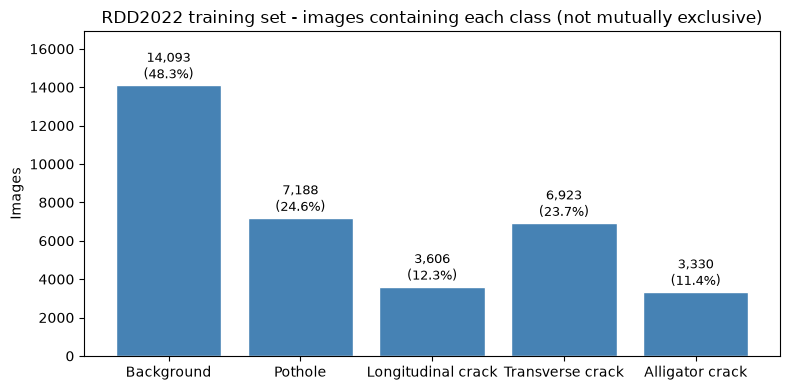

Total training images: 29,202
Images with more than one defect type: 5,044 (17.3%) -- this is the signal a single-label "most frequent class" scheme would have discarded.
Positive class weights (clamped to 10): [3.0626044273376465, 7.098169803619385, 3.218113422393799, 7.769369602203369]


In [3]:
from collections import Counter
from src.datasets.rdd2022 import parse_annotation, NUM_DEFECT_CLASSES

CLASS_NAMES = ['Pothole', 'Longitudinal crack', 'Transverse crack', 'Alligator crack']

label_counts: Counter = Counter()
background_count = 0
multi_label_count = 0
total = 0

for country in countries:
    ann_dir = RDD2022_DIR / country / 'train' / 'annotations' / 'xmls'
    if not ann_dir.is_dir():
        continue
    for xml_path in sorted(ann_dir.glob('*.xml')):
        total += 1
        anns = parse_annotation(xml_path)
        present = {a['label'] for a in anns}
        if not present:
            background_count += 1
        else:
            for label in present:
                label_counts[label] += 1
            if len(present) > 1:
                multi_label_count += 1

counts = [label_counts[c] for c in range(1, NUM_DEFECT_CLASSES + 1)]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(['Background'] + CLASS_NAMES, [background_count] + counts, color='steelblue', edgecolor='white')
ax.set_ylabel('Images')
ax.set_title('RDD2022 training set - images containing each class (not mutually exclusive)')
for bar, count in zip(bars, [background_count] + counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 150,
        f'{count:,}\n({count / total:.1%})',
        ha='center', va='bottom', fontsize=9,
    )
ax.set_ylim(0, max([background_count] + counts) * 1.2)
plt.tight_layout()
plt.savefig('class_distribution_rdd2022.png', dpi=120)
plt.show()

print(f'Total training images: {total:,}')
print(
    f'Images with more than one defect type: {multi_label_count:,} '
    f'({multi_label_count / total:.1%}) -- this is the signal a single-label '
    f'"most frequent class" scheme would have discarded.'
)

# Class-weighted loss: rare classes get a higher positive weight so the
# model isn't just rewarded for predicting "no defect" everywhere.
pos_weight = torch.tensor(
    [(total - label_counts[c]) / max(label_counts[c], 1) for c in range(1, NUM_DEFECT_CLASSES + 1)],
    dtype=torch.float32,
).clamp(max=10.0)
print(f'Positive class weights (clamped to 10): {pos_weight.tolist()}')

## 2. Build the model

We load EfficientNet-B4 pre-trained on ImageNet and replace its classifier
head with a linear layer sized to the four defect classes, one independent
sigmoid output per class (multi-label, not softmax). `drop_rate` and
`drop_path_rate` add head dropout and stochastic depth across the backbone --
both needed because a full fine-tune of a 17.5M-parameter model on ~25k
images overfits fast otherwise. The loss is `BCEWithLogitsLoss` with the
`pos_weight` computed above, so rare defect classes aren't drowned out by
the dominant background/negative signal. AdamW is used with
`ReduceLROnPlateau`, which cuts the learning rate when validation F1 stalls
instead of on a fixed schedule that might fire after training has already
stopped.

In [4]:
model = build_efficientnet(
    num_classes=RDD2022_NUM_CLASSES,
    pretrained=True,
    drop_rate=EFFICIENTNET_DROP_RATE,
    drop_path_rate=EFFICIENTNET_DROP_PATH_RATE,
)
model = model.to(DEVICE)

n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {n_params:,}')

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(DEVICE))
optimizer = optim.AdamW(
    model.parameters(),
    lr=EFFICIENTNET_LR,
    weight_decay=EFFICIENTNET_WEIGHT_DECAY,
 )
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.1,
    patience=3,
 )
scaler = torch.amp.GradScaler(
    'cuda',
    enabled=DEVICE.type == 'cuda',
 )

Trainable parameters: 17,555,788


## 3. Training loop

Each epoch runs one pass over the training set and one pass over the
validation set. Accuracy isn't a useful signal here -- with background
dominating the dataset, a model that predicts "no defect" everywhere would
still score high -- so both loops report macro-F1 (thresholded sigmoid
predictions vs. the multi-hot targets) instead. The best checkpoint (by
validation macro-F1) is saved to disk, and `ReduceLROnPlateau` also watches
validation macro-F1 to decide when to cut the learning rate.

In [5]:
from sklearn.metrics import f1_score


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    device: torch.device,
    optimizer: optim.Optimizer | None = None,
    scaler: torch.amp.GradScaler | None = None,
    desc: str = 'Train',
) -> tuple[float, float]:
    """
    One pass over loader. Trains if optimizer is given, otherwise evaluates.

    Returns (avg loss, macro-F1) using RDD2022_DEFECT_THRESHOLD to binarize
    the sigmoid outputs before scoring.
    """
    is_train = optimizer is not None
    model.train(is_train)

    total_loss = 0.0
    total = 0
    all_preds = []
    all_labels = []

    context = torch.enable_grad() if is_train else torch.no_grad()
    with context:
        for images, labels in tqdm(loader, desc=desc, leave=False):
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            if is_train:
                optimizer.zero_grad(set_to_none=True)

            with torch.autocast(
                device_type=device.type,
                dtype=torch.float16,
                enabled=device.type == 'cuda',
            ):
                logits = model(images)
                loss = criterion(logits, labels)

            if is_train:
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

            total_loss += loss.item() * images.size(0)
            total += images.size(0)
            preds = (torch.sigmoid(logits) > RDD2022_DEFECT_THRESHOLD).float()
            all_preds.append(preds.detach().cpu())
            all_labels.append(labels.detach().cpu())

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return total_loss / total, macro_f1

In [6]:
CHECKPOINT_DIR.mkdir(exist_ok=True)

history: dict[str, list[float]] = {
    'train_loss': [], 'train_f1': [],
    'val_loss':   [], 'val_f1':   [],
}
best_val_f1 = 0.0
patience = 8
min_delta = 1e-3
epochs_without_improvement = 0

for epoch in range(1, EFFICIENTNET_EPOCHS + 1):
    train_loss, train_f1 = run_epoch(
        model, train_loader, criterion, DEVICE,
        optimizer=optimizer, scaler=scaler, desc='Train',
    )
    val_loss, val_f1 = run_epoch(
        model, val_loader, criterion, DEVICE, desc='Val  ',
    )
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_f1'].append(val_f1)

    current_lr = optimizer.param_groups[0]['lr']
    print(
        f'Epoch {epoch}/{EFFICIENTNET_EPOCHS}  '
        f'train_loss={train_loss:.4f}  train_f1={train_f1:.3f}  '
        f'val_loss={val_loss:.4f}  val_f1={val_f1:.3f}  lr={current_lr:.2e}'
    )

    if val_f1 > best_val_f1 + min_delta:
        best_val_f1 = val_f1
        epochs_without_improvement = 0
        torch.save(model.state_dict(), RDD2022_CHECKPOINT)
        print(f'  Saved best checkpoint (val_f1={best_val_f1:.3f})')
    else:
        epochs_without_improvement += 1
        print(
            f'  No improvement for {epochs_without_improvement}/{patience} epoch(s)'
        )

    if epochs_without_improvement >= patience:
        print(f'Early stopping after epoch {epoch}.')
        break

print(
    f'\nTraining complete. Best val macro-F1: {best_val_f1:.3f} '
    f'after {len(history["val_f1"])} epoch(s)'
 )

Train:   0%|          | 0/1552 [00:00<?, ?it/s]

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 1/50  train_loss=0.9450  train_f1=0.431  val_loss=0.7572  val_f1=0.560  lr=1.00e-04
  Saved best checkpoint (val_f1=0.560)


Train:   0%|          | 0/1552 [00:00<?, ?it/s]

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 38/50  train_loss=0.1232  train_f1=0.918  val_loss=0.9996  val_f1=0.728  lr=1.00e-07
  No improvement for 7/8 epoch(s)


Train:   0%|          | 0/1552 [00:00<?, ?it/s]

Val  :   0%|          | 0/274 [00:00<?, ?it/s]

Epoch 39/50  train_loss=0.1217  train_f1=0.921  val_loss=0.9933  val_f1=0.724  lr=1.00e-07
  No improvement for 8/8 epoch(s)
Early stopping after epoch 39.

Training complete. Best val macro-F1: 0.727 after 39 epoch(s)


## 4. Training curves

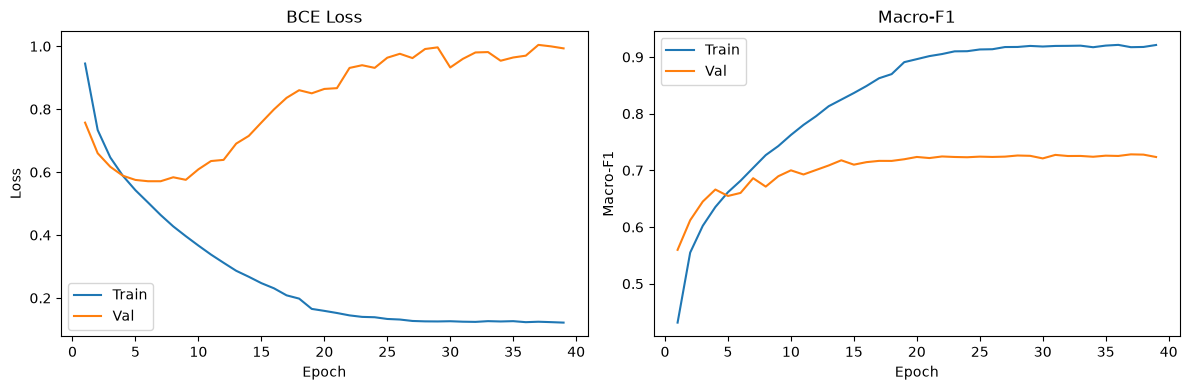

Saved training_curves_rdd2022.png for 39 epoch(s)


In [7]:
epochs = range(1, len(history['train_loss']) + 1)
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

axs[0].plot(epochs, history['train_loss'], label='Train')
axs[0].plot(epochs, history['val_loss'],   label='Val')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('BCE Loss')
axs[0].legend()

axs[1].plot(epochs, history['train_f1'], label='Train')
axs[1].plot(epochs, history['val_f1'],   label='Val')
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('Macro-F1')
axs[1].set_title('Macro-F1')
axs[1].legend()

plt.tight_layout()
plt.savefig('training_curves_rdd2022.png', dpi=120)
plt.show()
print(f'Saved training_curves_rdd2022.png for {len(history["train_loss"])} epoch(s)')

## 5. Per-class metrics on the validation set

Overall accuracy can mask a model that learned to predict the majority class.
Per-class precision, recall, and F1, computed independently for each of the
four defect classes against their own binary targets, give a clearer
picture of where the model is strong and where it struggles.

In [8]:
from sklearn.metrics import classification_report

# Reload the best checkpoint before evaluating.
model.load_state_dict(torch.load(RDD2022_CHECKPOINT, map_location=DEVICE))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Evaluating'):
        logits = model(images.to(DEVICE))
        preds = (torch.sigmoid(logits) > RDD2022_DEFECT_THRESHOLD).float()
        all_preds.append(preds.cpu())
        all_labels.append(labels)

all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, zero_division=0))

no_defect_true = all_labels.sum(axis=1) == 0
no_defect_pred = all_preds.sum(axis=1) == 0
print(f'No-defect agreement: {(no_defect_true == no_defect_pred).mean():.3f}')

Evaluating:   0%|          | 0/274 [00:00<?, ?it/s]

                    precision    recall  f1-score   support

           Pothole       0.67      0.72      0.69      1089
Longitudinal crack       0.59      0.72      0.65       550
  Transverse crack       0.81      0.87      0.84      1065
   Alligator crack       0.71      0.74      0.73       535

         micro avg       0.71      0.77      0.74      3239
         macro avg       0.70      0.76      0.73      3239
      weighted avg       0.71      0.77      0.74      3239
       samples avg       0.38      0.41      0.38      3239

No-defect agreement: 0.863
